# CWRU Bearing Dataset — Exploratory Data Analysis (EDA)

Notebook này đọc và khám phá dataset **CWRU Bearing Data Center**, với cấu trúc thư mục:

```
data/raw/
├── 12k_Drive_End_Bearing_Fault_Data/
│   ├── B/   (Ball fault)
│   │   ├── 007/ 014/ 021/ 028/   -> mỗi thư mục 4 file .mat (load 0-3 hp)
│   ├── IR/  (Inner Race fault)
│   └── OR/  (Outer Race fault)
└── Normal/
    └── 97_Normal_0.mat ... 100_Normal_3.mat
```

**Nội dung:**
1. Đọc file `.mat`, trích xuất tín hiệu (kênh DE) và RPM
2. Quét toàn bộ dataset → bảng manifest (metadata)
3. Trích xuất đặc trưng thống kê miền thời gian (RMS, Kurtosis, Skewness, Crest Factor...)
4. Trực quan hóa: phân bố lớp, waveform, FFT, spectrogram, boxplot so sánh đặc trưng


In [7]:
# !pip install numpy scipy pandas matplotlib

import os
import re
import glob
import warnings

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy import signal
from scipy.stats import kurtosis, skew
import matplotlib.pyplot as plt
from typing import Dict, Optional, Union

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.dpi"] = 100


In [10]:
# ==== CẤU HÌNH ====
DATA_ROOT = "../data/raw"
SAMPLING_RATE = 12000
N_SAMPLES_PLOT = 2000 
LOAD_HP_FOR_PLOTS = 0 
OUTPUT_DIR = "eda_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## 1. Đọc file `.mat` và trích xuất tín hiệu

In [8]:
def find_key(mat_dict, suffix):
    """Tìm key trong file .mat có đuôi khớp (vd '_DE_time', '_FE_time', 'RPM')."""
    for key in mat_dict.keys():
        if key.startswith("__"):
            continue
        if suffix.lower() in key.lower():
            return key
    return None


def load_mat_signal(filepath):
    """Đọc 1 file .mat CWRU, trả về dict chứa tín hiệu DE/FE/BA và RPM (nếu có)."""
    mat = sio.loadmat(filepath)

    # Khai báo kiểu tường minh: mỗi giá trị có thể là ndarray, float, hoặc None
    result: Dict[str, Optional[Union[np.ndarray, float]]] = {
        "DE": None, "FE": None, "BA": None, "RPM": None
    }

    de_key = find_key(mat, "_DE_time")
    fe_key = find_key(mat, "_FE_time")
    ba_key = find_key(mat, "_BA_time")
    rpm_key = find_key(mat, "RPM")

    if de_key:
        result["DE"] = mat[de_key].flatten().astype(float)
    if fe_key:
        result["FE"] = mat[fe_key].flatten().astype(float)
    if ba_key:
        result["BA"] = mat[ba_key].flatten().astype(float)
    if rpm_key:
        try:
            result["RPM"] = float(mat[rpm_key].flatten()[0])
        except Exception:
            result["RPM"] = None

    return result


## 2. Quét toàn bộ dataset → bảng manifest (metadata)

In [28]:
def parse_metadata_from_path(filepath, data_root):
    """
    Suy ra nhãn (fault_type, fault_size, load, position) từ đường dẫn file.
    Ví dụ: .../B/007/118_0.mat -> fault_type='B', fault_size='007', position='None'
    Ví dụ: .../OR/007/@12/234_0.mat -> fault_type='OR', fault_size='007', position='@12'
    Ví dụ: .../Normal/97_Normal_0.mat -> fault_type='Normal', fault_size='None', position='None'
    """
    rel = os.path.relpath(filepath, data_root)
    parts = rel.split(os.sep)
    filename = parts[-1]

    m = re.search(r"_(\d)\.mat$", filename)
    load = int(m.group(1)) if m else None

    if "Normal" in rel:
        fault_type = "Normal"
        fault_size = "None"
        position = "None"
    else:
        sub_parts = parts[:-1]  # bỏ tên file
        fault_type = sub_parts[-2] if len(sub_parts) >= 2 else sub_parts[0]
        fault_size = sub_parts[-1]
        if fault_size.startswith("@"):
            # OR có thêm subfolder vị trí lỗi (@3/@6/@12)
            position = fault_size
            fault_size = sub_parts[-2]
            fault_type = sub_parts[-3]
        else:
            position = "None"

    return {
        "filepath": filepath,
        "filename": filename,
        "fault_type": fault_type,
        "fault_size": fault_size,
        "position": position,
        "load_hp": load,
    }


def build_manifest(data_root):
    """Quét toàn bộ file .mat trong data_root, trả về DataFrame manifest."""
    mat_files = glob.glob(os.path.join(data_root, "**", "*.mat"), recursive=True)
    if not mat_files:
        raise FileNotFoundError(
            f"Không tìm thấy file .mat nào trong '{data_root}'. Kiểm tra lại DATA_ROOT."
        )

    records = [parse_metadata_from_path(fp, data_root) for fp in mat_files]
    df = pd.DataFrame(records)
    df["class_label"] = df.apply(
        lambda r: "Normal" if r["fault_type"] == "Normal"
        else f"{r['fault_type']}_{r['fault_size']}" + (f"_{r['position']}" if r['position'] != "None" else ""),
        axis=1,
    )
    return df


manifest = build_manifest(DATA_ROOT)
print(f"Tổng số file .mat tìm thấy: {len(manifest)}")
manifest.head()

Tổng số file .mat tìm thấy: 64


,filepath,filename,fault_type,fault_size,position,load_hp,class_label
0,../data/raw\12k_Drive_End_Bearing_Fault_Data\B...,118_0.mat,B,007,None,0,B_007
1,../data/raw\12k_Drive_End_Bearing_Fault_Data\B...,119_1.mat,B,007,None,1,B_007
2,../data/raw\12k_Drive_End_Bearing_Fault_Data\B...,120_2.mat,B,007,None,2,B_007
3,../data/raw\12k_Drive_End_Bearing_Fault_Data\B...,121_3.mat,B,007,None,3,B_007
4,../data/raw\12k_Drive_End_Bearing_Fault_Data\B...,185_0.mat,B,014,None,0,B_014


In [29]:
# Số lượng file theo từng lớp (kiểm tra cân bằng dữ liệu)
manifest["class_label"].value_counts().sort_index()


class_label
B_007         4
B_014         4
B_021         4
B_028         4
IR_007        4
IR_014        4
IR_021        4
IR_028        4
Normal        4
OR_007_@12    4
OR_007_@3     4
OR_007_@6     4
OR_014        4
OR_021_@12    4
OR_021_@3     4
OR_021_@6     4
Name: count, dtype: int64

## 3. Trích xuất đặc trưng thống kê miền thời gian

In [30]:
def extract_time_features(sig):
    """Tính các đặc trưng thống kê phổ biến dùng để chẩn đoán lỗi vòng bi."""
    sig = np.asarray(sig, dtype=float)
    rms = np.sqrt(np.mean(sig ** 2))
    peak = np.max(np.abs(sig))
    mean_abs = np.mean(np.abs(sig))
    return {
        "mean": np.mean(sig),
        "std": np.std(sig),
        "rms": rms,
        "peak": peak,
        "kurtosis": kurtosis(sig),
        "skewness": skew(sig),
        "crest_factor": peak / rms if rms > 0 else np.nan,
        "shape_factor": rms / mean_abs if mean_abs > 0 else np.nan,
        "n_samples": len(sig),
    }


def enrich_manifest_with_signals_and_features(df):
    """Đọc tín hiệu DE của từng file, gắn thêm đặc trưng thống kê vào manifest."""
    feature_rows = []
    signals_cache = {}

    for idx, row in df.iterrows():
        data = load_mat_signal(row["filepath"])
        de_signal = data["DE"]

        if de_signal is None:
            print(f"[Cảnh báo] Không tìm thấy kênh DE trong: {row['filename']}")
            feature_rows.append({})
            continue

        feats = extract_time_features(de_signal)
        feats["rpm"] = data["RPM"]
        feature_rows.append(feats)
        signals_cache[row["filepath"]] = de_signal

    feat_df = pd.DataFrame(feature_rows)
    full_df = pd.concat([df.reset_index(drop=True), feat_df.reset_index(drop=True)], axis=1)
    return full_df, signals_cache


full_df, signals_cache = enrich_manifest_with_signals_and_features(manifest)
full_df.head()

,filepath,filename,fault_type,fault_size,position,load_hp,class_label,mean,std,rms,peak,kurtosis,skewness,crest_factor,shape_factor,n_samples,rpm
0,../data/raw\12k_Drive_End_Bearing_Fault_Data\B...,118_0.mat,B,007,None,0,B_007,0.012607,0.138662,0.139234,0.607020,-0.015284,-0.008854,4.359725,1.252615,122571,1796.0
1,../data/raw\12k_Drive_End_Bearing_Fault_Data\B...,119_1.mat,B,007,None,1,B_007,0.003892,0.139014,0.139068,0.659649,-0.036246,0.007453,4.743345,1.250417,121410,1772.0
2,../data/raw\12k_Drive_End_Bearing_Fault_Data\B...,120_2.mat,B,007,None,2,B_007,0.004564,0.147181,0.147252,0.604584,-0.168587,0.027124,4.105779,1.244213,121556,1748.0
3,../data/raw\12k_Drive_End_Bearing_Fault_Data\B...,121_3.mat,B,007,None,3,B_007,0.004200,0.153577,0.153635,0.720562,-0.110270,0.020412,4.690096,1.246847,121556,1722.0
4,../data/raw\12k_Drive_End_Bearing_Fault_Data\B...,185_0.mat,B,014,None,0,B_014,0.004688,0.152642,0.152714,2.278153,14.769217,0.225132,14.917809,1.520264,121846,1796.0


In [31]:
# Lưu manifest đầy đủ đặc trưng ra CSV
manifest_path = os.path.join(OUTPUT_DIR, "manifest_features.csv")
full_df.drop(columns=["filepath"]).to_csv(manifest_path, index=False, encoding="utf-8-sig")
print(f"[Đã lưu] {manifest_path}")

[Đã lưu] eda_outputs\manifest_features.csv


## 4. Thống kê mô tả theo từng lớp

In [32]:
summary = full_df.groupby("class_label")[
    ["rms", "kurtosis", "skewness", "crest_factor", "peak"]
].mean().round(4)

summary_path = os.path.join(OUTPUT_DIR, "feature_summary_by_class.csv")
summary.to_csv(summary_path, encoding="utf-8-sig")
print(f"[Đã lưu] {summary_path}")
summary


[Đã lưu] eda_outputs\feature_summary_by_class.csv


,rms,kurtosis,skewness,crest_factor,peak
class_label,,,,,
B_007,0.1448,-0.0826,0.0115,4.4747,0.6480
B_014,0.1427,9.8043,0.1370,13.0316,1.8615
B_021,0.1225,3.0905,0.0118,8.6422,1.0890
B_028,2.0994,0.8633,0.0473,5.2945,11.1027
IR_007,0.2994,2.4482,0.0929,5.5417,1.6577
IR_014,0.1768,17.9729,0.0003,11.4317,2.0121
IR_021,0.4762,4.8787,0.2776,7.7550,3.6780
IR_028,0.8351,0.2989,0.1270,5.2697,4.4009
Normal,0.0681,-0.1043,-0.1273,4.8242,0.3274


## 5. Trực quan hóa

In [33]:
def pick_representative_files(df, load_hp=0):
    """Chọn 1 file đại diện cho mỗi class_label (ưu tiên load_hp chỉ định)."""
    reps = {}
    for label, group in df.groupby("class_label"):
        sub = group[group["load_hp"] == load_hp]
        chosen = sub.iloc[0] if len(sub) > 0 else group.iloc[0]
        reps[label] = chosen["filepath"]
    return reps


rep_files = pick_representative_files(full_df, load_hp=LOAD_HP_FOR_PLOTS)
rep_files

{'B_007': '../data/raw\\12k_Drive_End_Bearing_Fault_Data\\B\\007\\118_0.mat',
 'B_014': '../data/raw\\12k_Drive_End_Bearing_Fault_Data\\B\\014\\185_0.mat',
 'B_021': '../data/raw\\12k_Drive_End_Bearing_Fault_Data\\B\\021\\222_0.mat',
 'B_028': '../data/raw\\12k_Drive_End_Bearing_Fault_Data\\B\\028\\3005_0.mat',
 'IR_007': '../data/raw\\12k_Drive_End_Bearing_Fault_Data\\IR\\007\\105_0.mat',
 'IR_014': '../data/raw\\12k_Drive_End_Bearing_Fault_Data\\IR\\014\\169_0.mat',
 'IR_021': '../data/raw\\12k_Drive_End_Bearing_Fault_Data\\IR\\021\\209_0.mat',
 'IR_028': '../data/raw\\12k_Drive_End_Bearing_Fault_Data\\IR\\028\\3001_0.mat',
 'Normal': '../data/raw\\Normal\\97_Normal_0.mat',
 'OR_007_@12': '../data/raw\\12k_Drive_End_Bearing_Fault_Data\\OR\\007\\@12\\156_0.mat',
 'OR_007_@3': '../data/raw\\12k_Drive_End_Bearing_Fault_Data\\OR\\007\\@3\\144_0.mat',
 'OR_007_@6': '../data/raw\\12k_Drive_End_Bearing_Fault_Data\\OR\\007\\@6\\130@6_0.mat',
 'OR_014': '../data/raw\\12k_Drive_End_Bearing_Fau

### 5.1 Phân bố số lượng file theo từng lớp

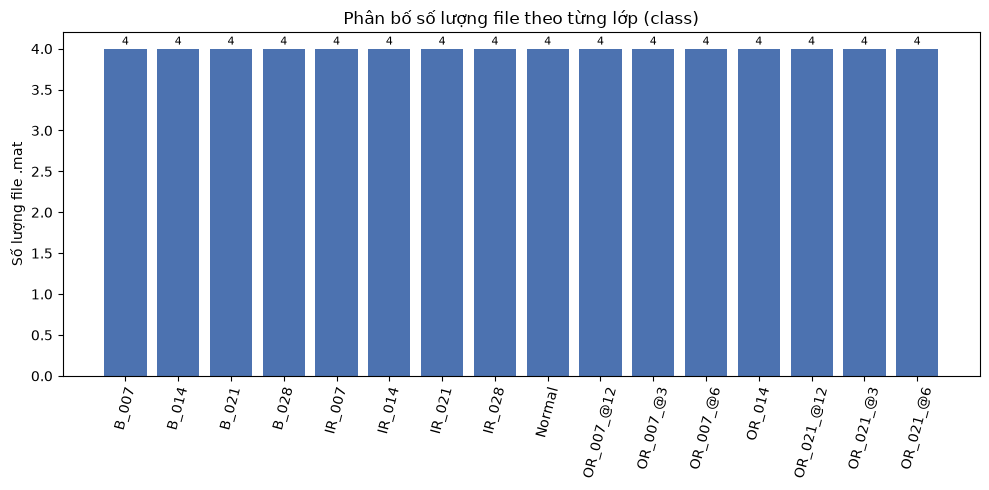

In [34]:
counts = full_df["class_label"].value_counts().sort_index()
labels = counts.index.tolist()
values = counts.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(labels, values, color="#4C72B0")
ax.set_title("Phân bố số lượng file theo từng lớp (class)")
ax.set_ylabel("Số lượng file .mat")
ax.tick_params(axis="x", rotation=75)
for i, v in enumerate(values):
    ax.text(i, v + 0.05, str(int(v)), ha="center", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), dpi=150)
plt.show()

### 5.2 Waveform (miền thời gian) — so sánh Normal vs từng loại lỗi

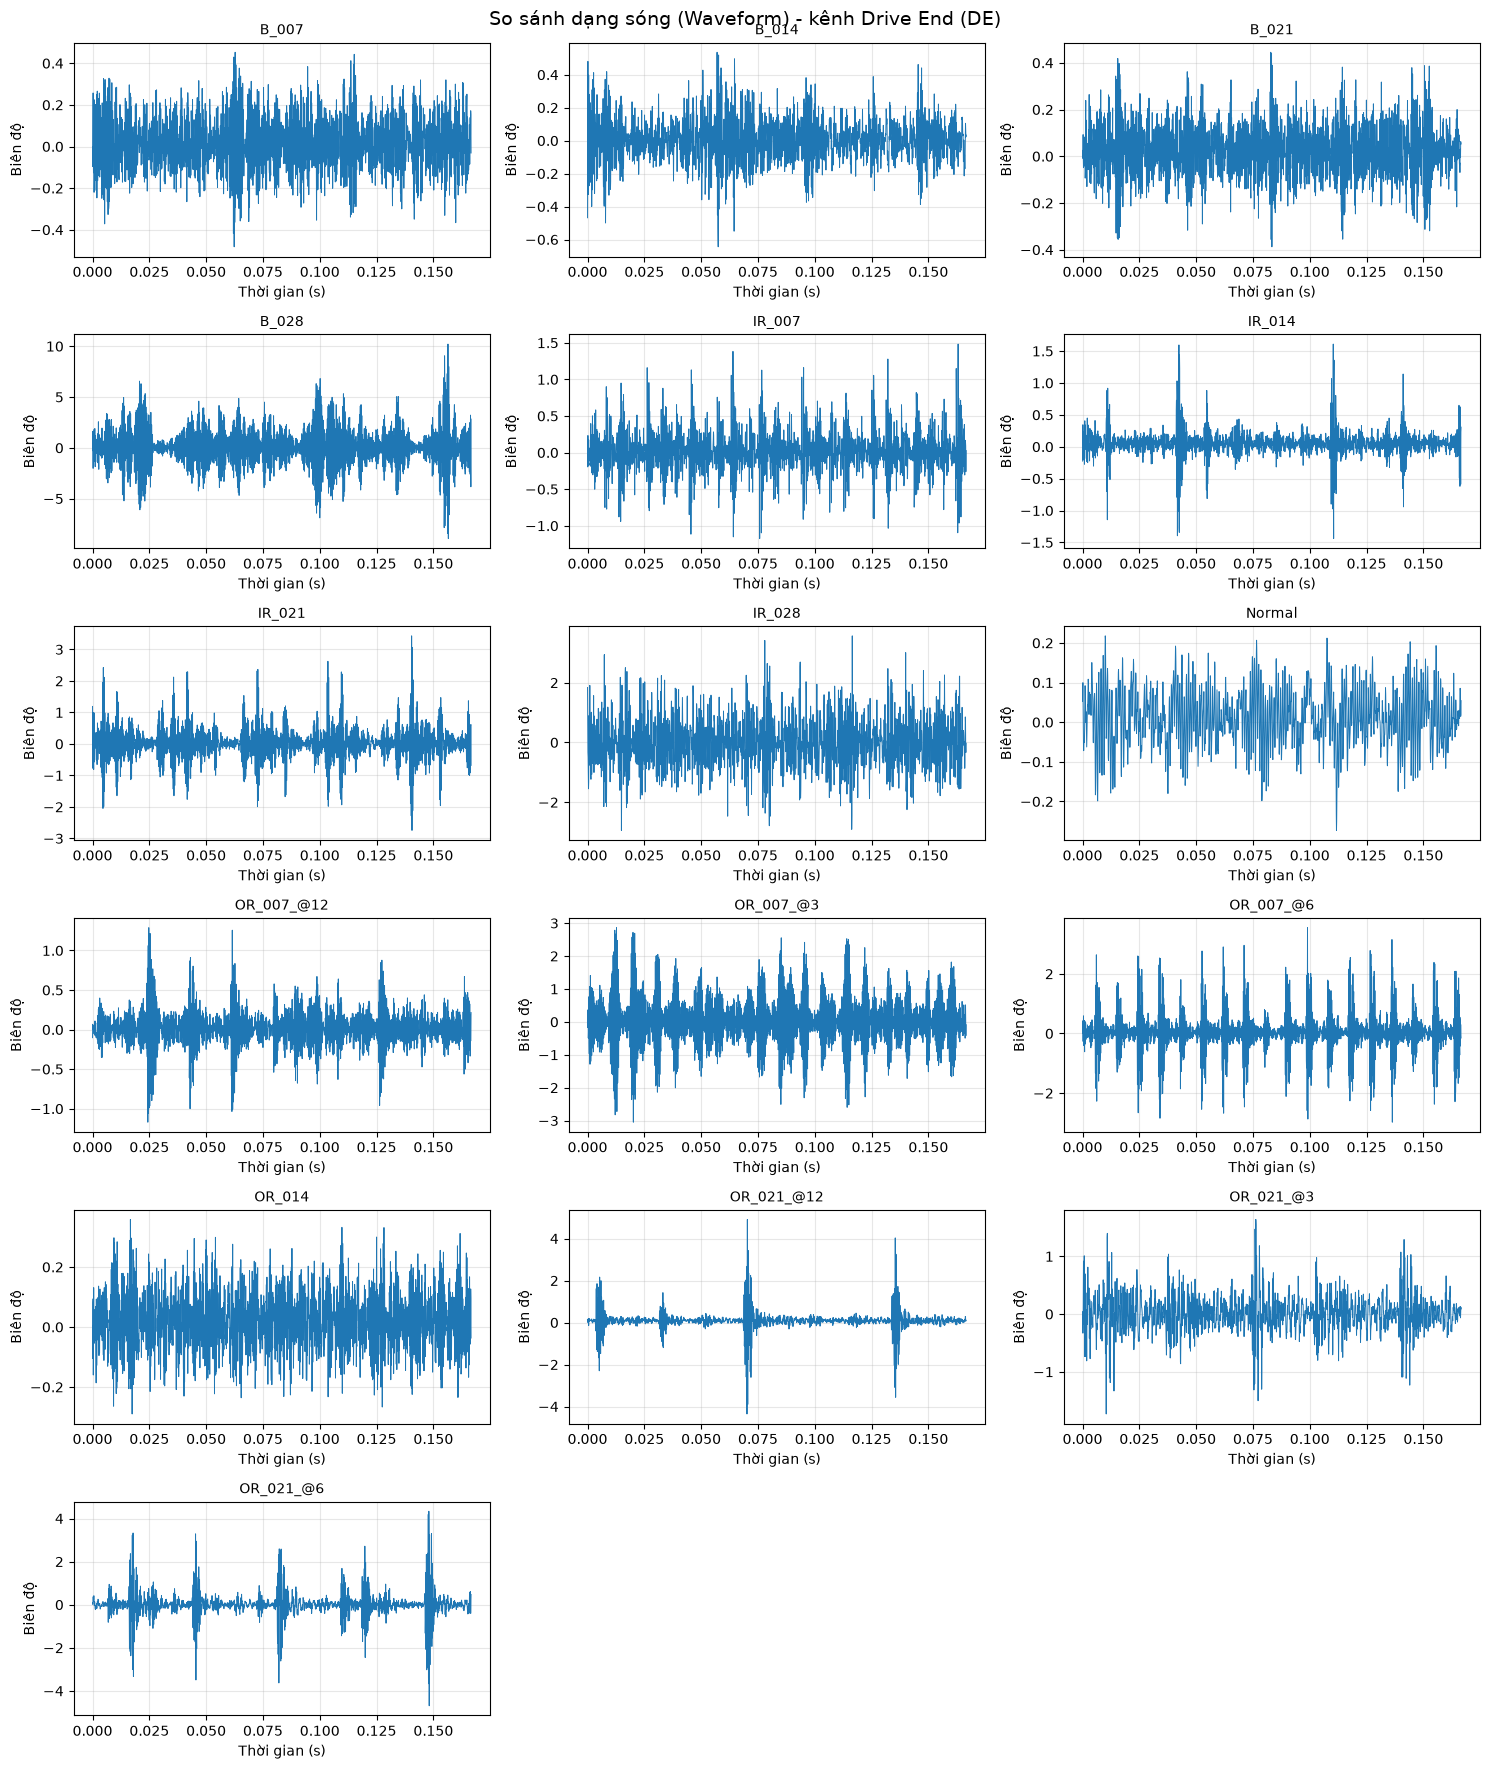

In [35]:
n = len(rep_files)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
axes = np.array(axes).flatten()

for ax, (label, fp) in zip(axes, rep_files.items()):
    sig = signals_cache.get(fp)
    if sig is None:
        continue
    t = np.arange(min(N_SAMPLES_PLOT, len(sig))) / SAMPLING_RATE
    ax.plot(t, sig[: len(t)], linewidth=0.7)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Thời gian (s)")
    ax.set_ylabel("Biên độ")
    ax.grid(alpha=0.3)

for ax in axes[len(rep_files):]:
    ax.axis("off")

fig.suptitle("So sánh dạng sóng (Waveform) - kênh Drive End (DE)", fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "waveform_comparison.png"), dpi=150)
plt.show()


### 5.3 Phổ FFT (miền tần số) — so sánh Normal vs từng loại lỗi

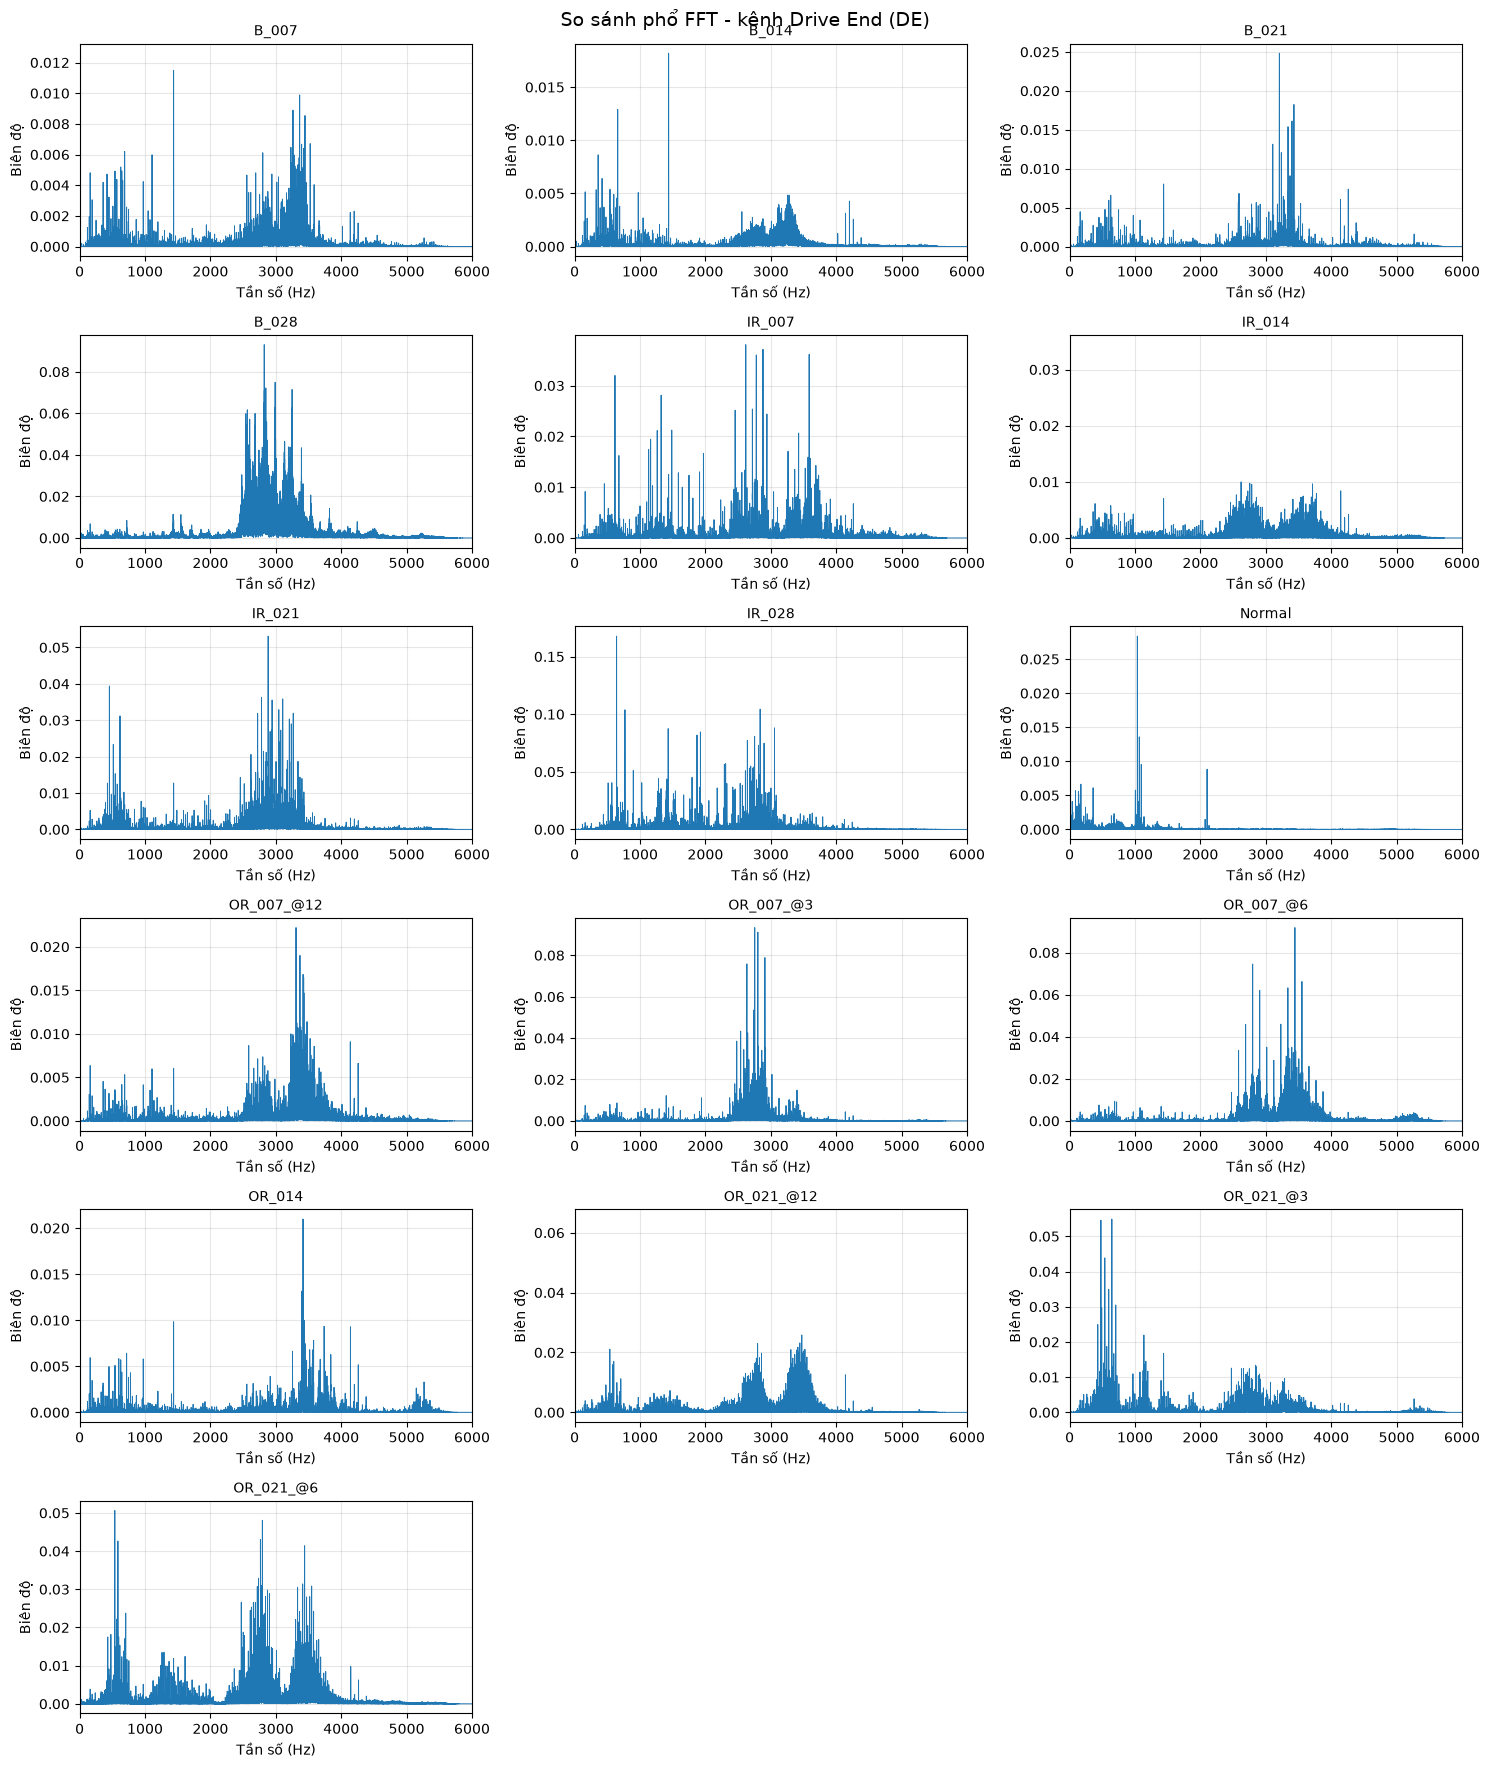

In [36]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
axes = np.array(axes).flatten()

for ax, (label, fp) in zip(axes, rep_files.items()):
    sig = signals_cache.get(fp)
    if sig is None:
        continue
    n_fft = len(sig)
    freqs = np.fft.rfftfreq(n_fft, d=1 / SAMPLING_RATE)
    mag = np.abs(np.fft.rfft(sig)) / n_fft

    ax.plot(freqs, mag, linewidth=0.7)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Tần số (Hz)")
    ax.set_ylabel("Biên độ")
    ax.set_xlim(0, SAMPLING_RATE / 2)
    ax.grid(alpha=0.3)

for ax in axes[len(rep_files):]:
    ax.axis("off")

fig.suptitle("So sánh phổ FFT - kênh Drive End (DE)", fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "fft_comparison.png"), dpi=150)
plt.show()


### 5.4 Spectrogram (thời gian – tần số – năng lượng)

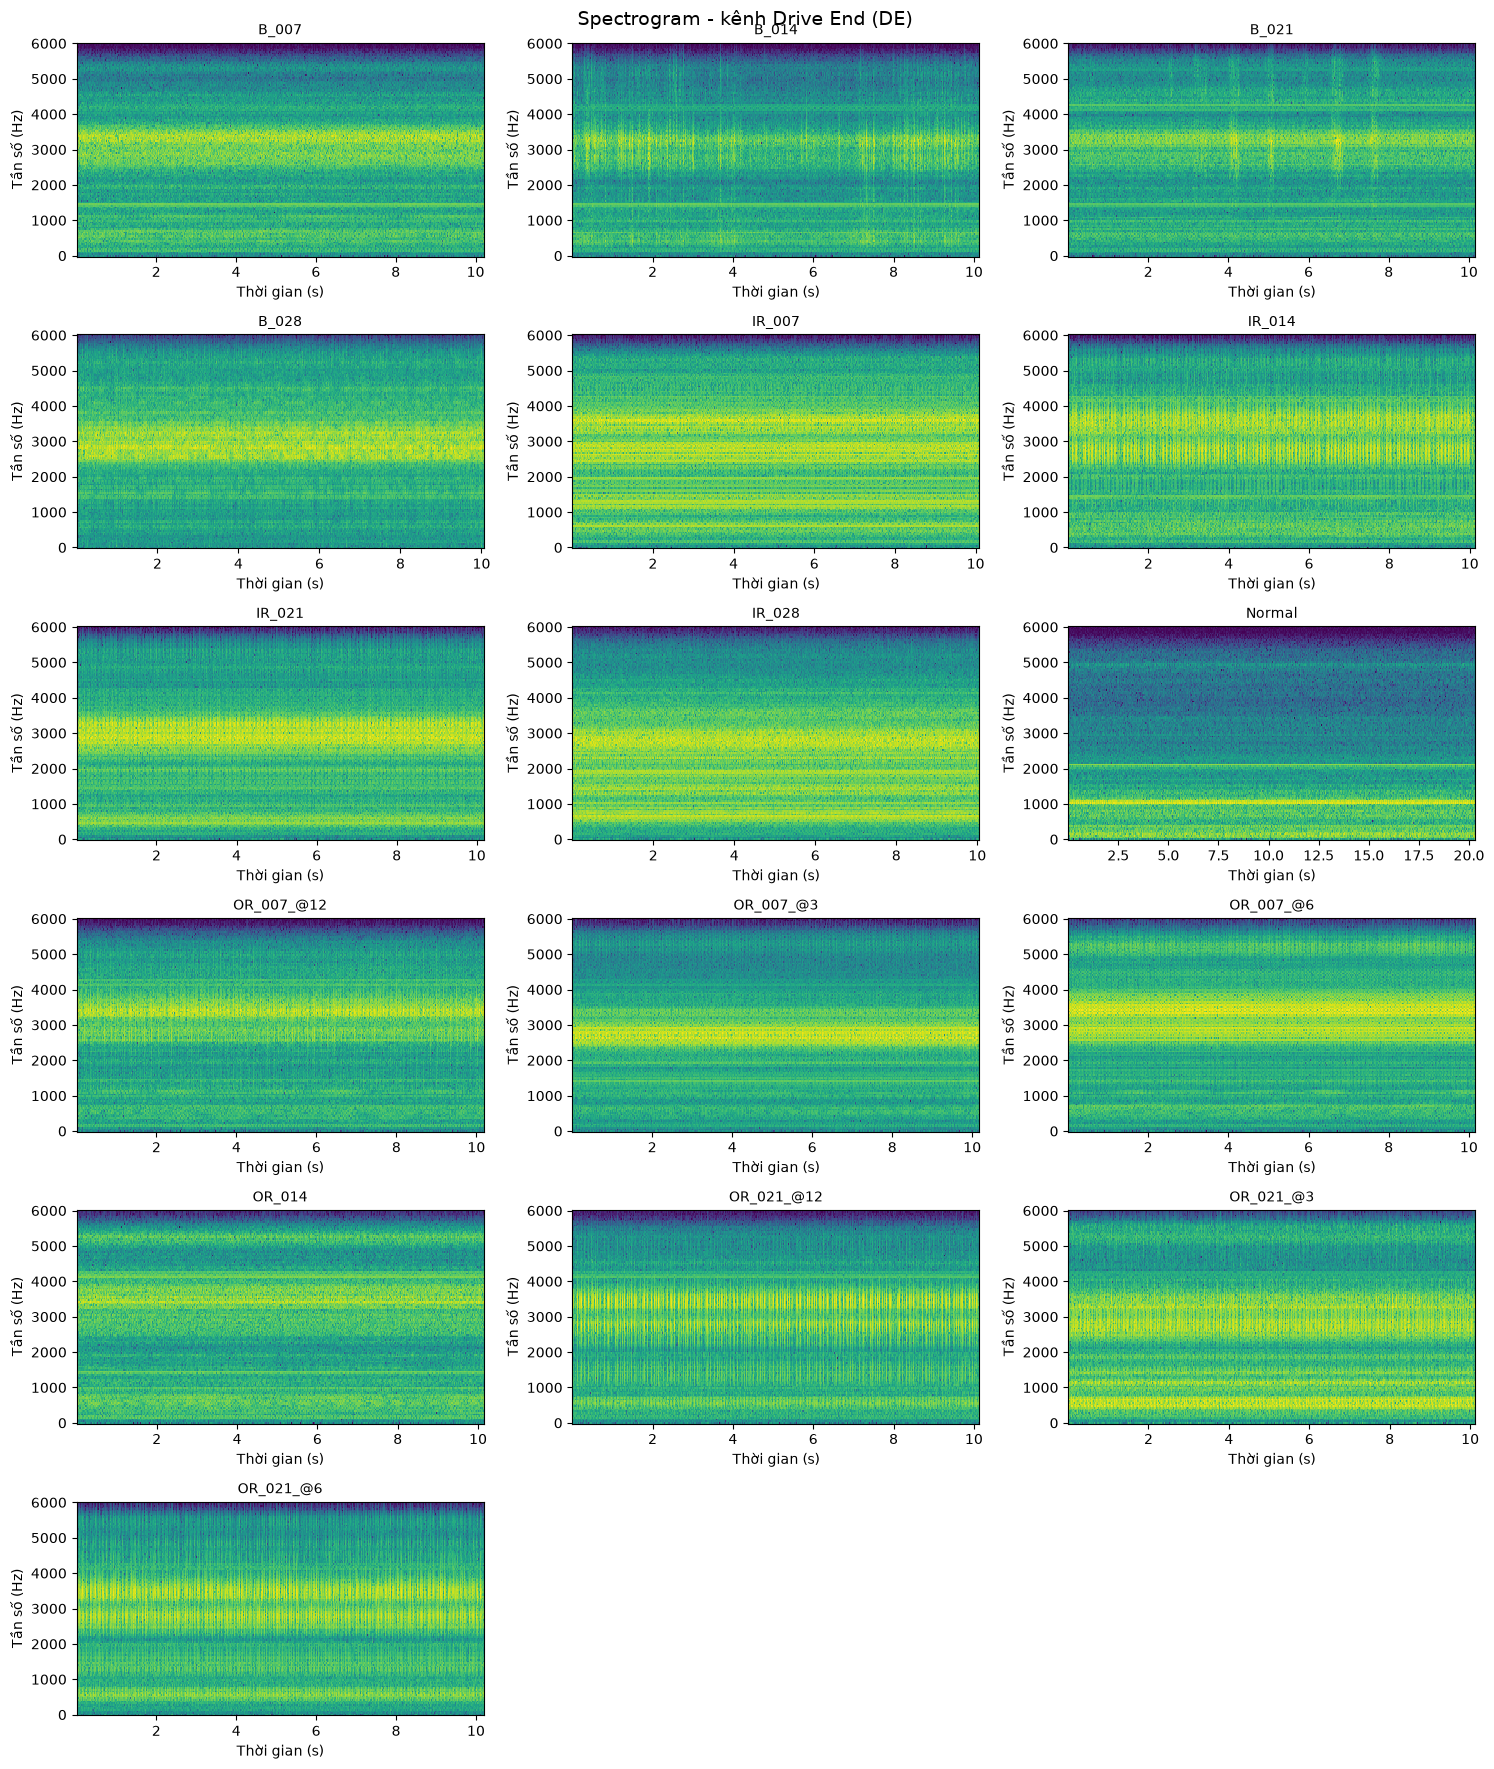

In [38]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
axes = np.array(axes).flatten()

for ax, (label, fp) in zip(axes, rep_files.items()):
    sig = signals_cache.get(fp)
    if sig is None:
        continue
    f, t, Sxx = signal.spectrogram(sig, fs=SAMPLING_RATE, nperseg=256, noverlap=128)
    ax.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-12), shading="auto", cmap="viridis")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Thời gian (s)")
    ax.set_ylabel("Tần số (Hz)")

for ax in axes[len(rep_files):]:
    ax.axis("off")

fig.suptitle("Spectrogram - kênh Drive End (DE)", fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "spectrogram_comparison.png"), dpi=150)
plt.show()


### 5.5 Boxplot so sánh đặc trưng thống kê giữa các lớp

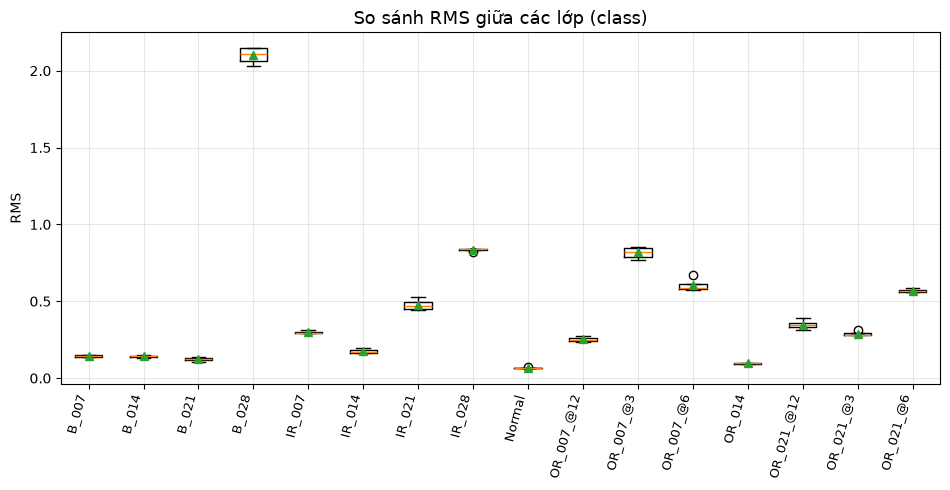

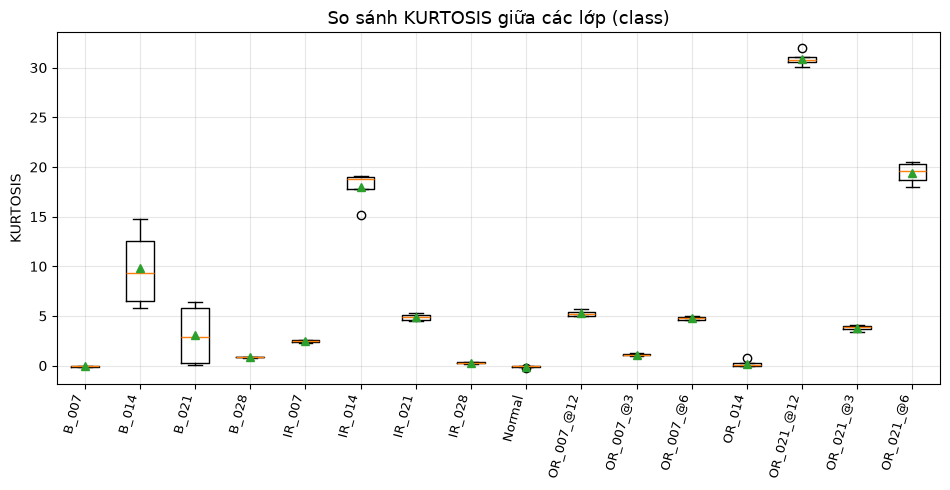

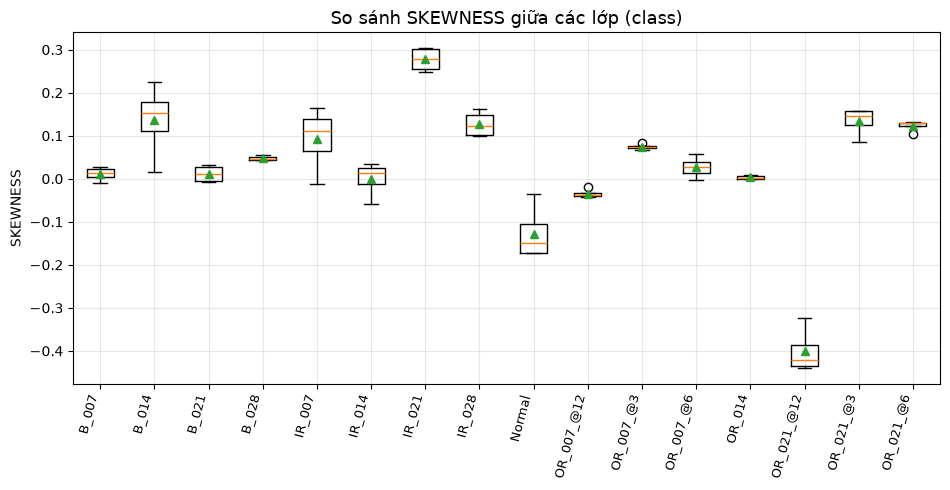

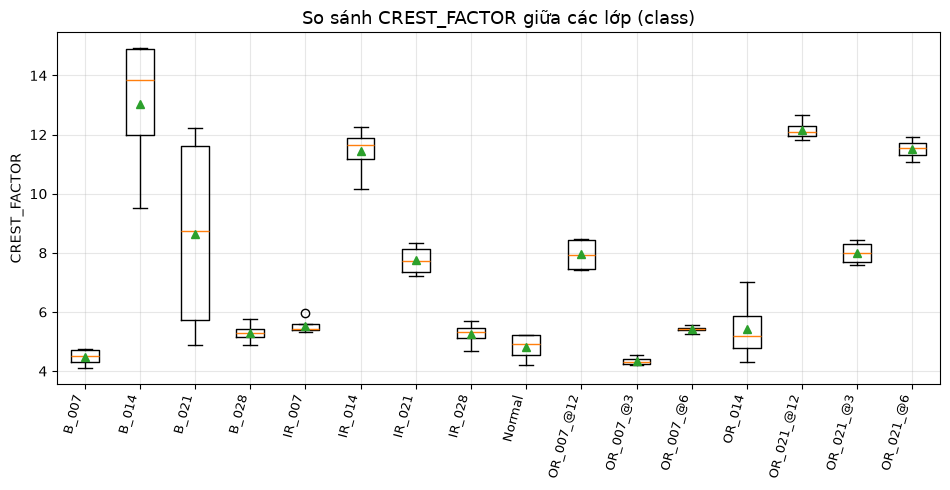

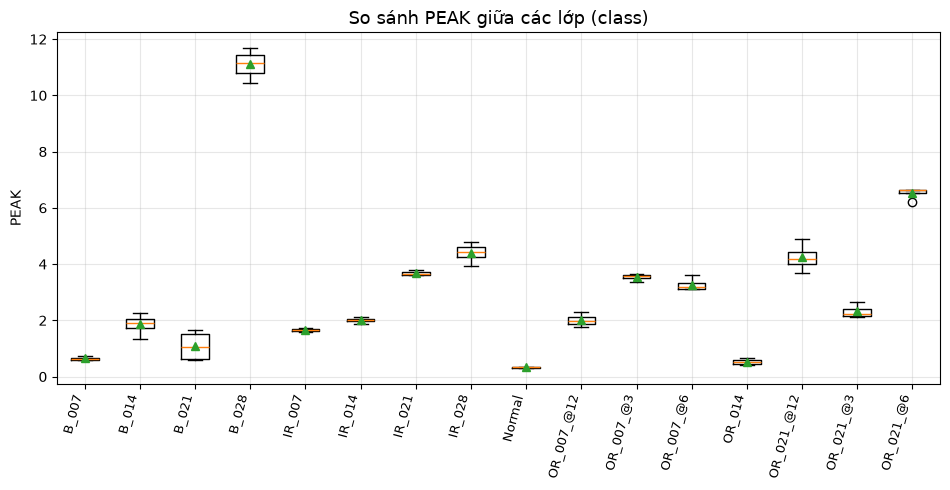

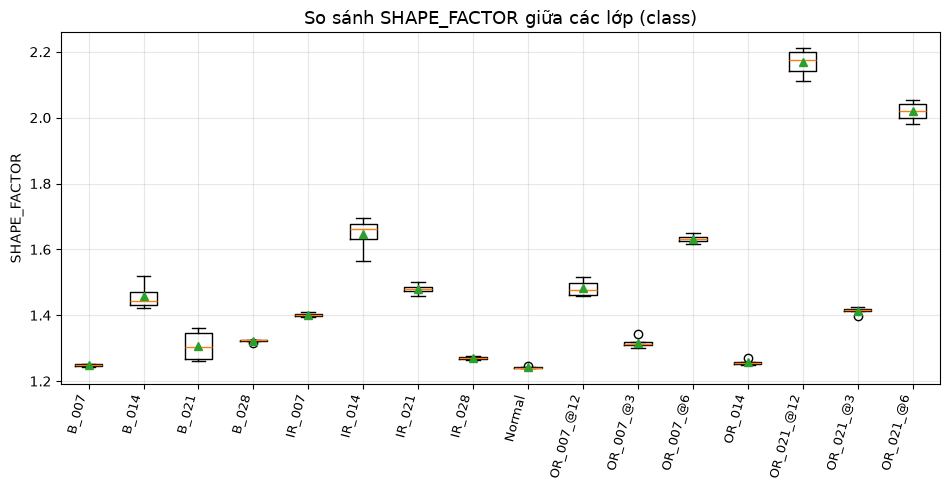

In [39]:
features = ["rms", "kurtosis", "skewness", "crest_factor", "peak", "shape_factor"]
labels = sorted(full_df["class_label"].unique())
grouped = full_df.groupby("class_label")

for feat in features:
    data_by_class = [
        grouped.get_group(lbl)[feat].dropna().to_numpy(dtype=float)
        for lbl in labels
    ]

    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 0.6), 5))
    ax.boxplot(data_by_class, showmeans=True)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=75, ha="right", fontsize=9)
    ax.set_title(f"So sánh {feat.upper()} giữa các lớp (class)", fontsize=13)
    ax.set_ylabel(feat.upper())
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, f"feature_boxplot_{feat}.png"), dpi=150)
    plt.show()